## 무신사 속옷/홈웨어 카테고리 EDA

무신사 속옷/홈웨어(카테고리 026) 인기순 상위 40개 상품과 상품별 리뷰(최대 20건, 총 543건)를 분석한다.

- 데이터: `musinsa_crawler.py`로 수집 (수집일 2026-07-08, 도움돼요순 리뷰)
- 원본 데이터는 저장소에 포함하지 않음(`data/`는 gitignore). 노트북 실행 전 크롤러로 먼저 수집 필요:
  ```bash
  python musinsa_crawler.py products --category 026 --pages 1
  python musinsa_crawler.py reviews --from-products data/products_026_YYYYMMDD.json --per-product 20
  ```
- 분석 질문
  1. 인기 상품의 가격대·할인 구조는 어떤가?
  2. 어떤 브랜드가 카테고리를 지배하는가?
  3. 평점은 상품 변별에 쓸 만한가? 아니라면 리뷰 텍스트에서 무엇을 읽어야 하는가?

In [1]:
import json
import re
from collections import Counter
from glob import glob

import pandas as pd
import matplotlib.pyplot as plt

# 차트 팔레트 — 시리즈는 파랑 단일 색, 긍/부정 비교만 파랑↔빨강 (극성 대비)
BLUE, RED = '#2a78d6', '#e34948'
INK, SECONDARY, MUTED, GRID = '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
SURFACE = '#fcfcfb'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',   # Windows 한글 폰트
    'axes.unicode_minus': False,
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
    'axes.edgecolor': '#c3c2b7',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': False, 'grid.color': GRID, 'grid.linewidth': 0.8,
    'axes.axisbelow': True,
    'text.color': INK, 'axes.labelcolor': SECONDARY,
    'xtick.color': MUTED, 'ytick.color': MUTED,
})

#### 데이터 로드 · 전처리

In [2]:
# 같은 카테고리를 여러 날 수집해도 최신 파일을 집도록 glob 사용
with open(sorted(glob('data/products_026_*.json'))[-1], encoding='utf-8') as f:
    prod = pd.DataFrame(json.load(f)).drop(columns=['_goods_no'])
with open(sorted(glob('data/reviews_026_*.json'))[-1], encoding='utf-8') as f:
    rev = pd.DataFrame(json.load(f))

prod.shape, rev.shape

((40, 11), (543, 6))

In [3]:
# 문자열 필드를 숫자로 변환
prod['가격'] = prod['Price'].str.replace(',', '').astype(int)
prod['할인율'] = prod['Discount Rate'].str.rstrip('%').astype(int)
prod['리뷰수'] = prod['Review Count'].str.replace(',', '').astype(int)
prod['평점'] = pd.to_numeric(prod['Rating'], errors='coerce')

rev['평점'] = pd.to_numeric(rev['Rating'])
rev['날짜'] = pd.to_datetime(rev['Review Date'])
rev['본문길이'] = rev['Review Body'].str.len()

prod[['Rank', 'Brand', 'Product Name', '가격', '할인율', '리뷰수', '평점']].head()

,Rank,Brand,Product Name,가격,할인율,리뷰수,평점
0,1,베리시,쿨핏 브라 볼륨핏&팬티 set,53900,29,1295,4.9
1,2,캘빈클라인 언더웨어,여성 아이콘 코튼 모달 AF 비키니_QF8520ADP7A,40500,10,2957,4.9
2,3,뉴욕웍스,레이스 새깅 쇼츠_블랙,17100,10,0,0.0
3,4,무신사 스탠다드 우먼,[쿨탠다드] 우먼즈 심리스 브라 [블랙],22430,25,29,4.7
4,5,아디다스 언더웨어,메쉬 쿨핏 서포트 브라팬티 GR,21900,45,1,5.0


#### 1. 가격대 분포

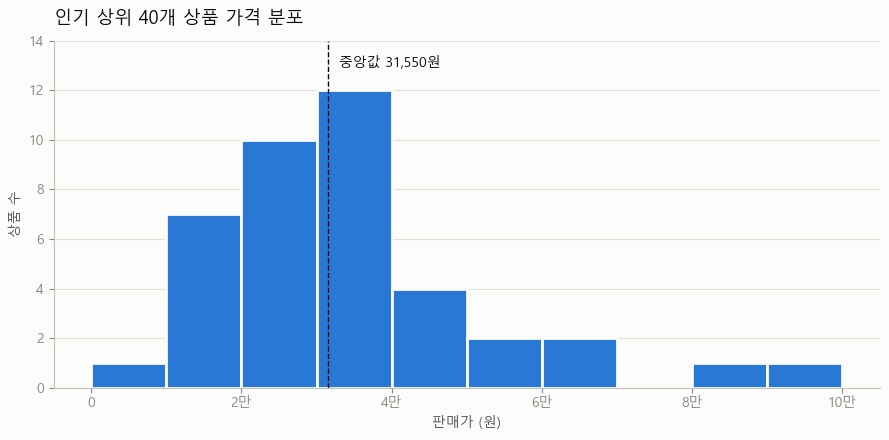

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(prod['가격'], bins=range(0, 100001, 10000), color=BLUE, edgecolor=SURFACE, linewidth=2)
med = prod['가격'].median()
ax.axvline(med, color=INK, linewidth=1, linestyle='--')
ax.set_ylim(0, 14)
ax.text(med + 1500, 13.4, f'중앙값 {med:,.0f}원', va='top', fontsize=10)
ax.set_xticks(range(0, 100001, 20000))
ax.set_xticklabels(['0', '2만', '4만', '6만', '8만', '10만'])
ax.set_xlabel('판매가 (원)')
ax.set_ylabel('상품 수')
ax.set_title('인기 상위 40개 상품 가격 분포', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

**가격대: 1~5만원이 주력, 중앙값 31,550원**

- 최저 6,400원 ~ 최고 92,900원. 평균(34,678원)이 중앙값보다 높은 오른쪽 꼬리 분포 — 소수의 고가 세트 상품(브라+팬티 세트, 파자마 세트)이 평균을 끌어올림
- 속옷/홈웨어는 아우터 대비 단가가 낮아 세트 구성으로 객단가를 올리는 상품이 상위권에 다수 포진

#### 2. 할인 구조

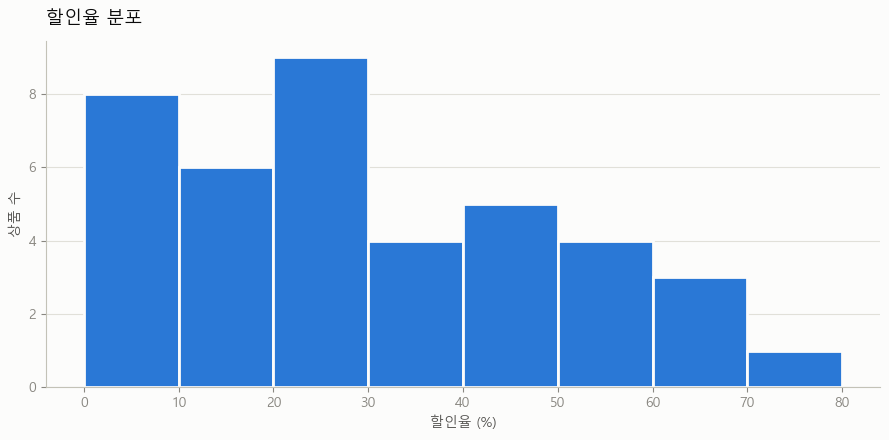

정가 판매(0%): 7개 / 40개
할인율 중앙값 25%, 최대 72%


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(prod['할인율'], bins=range(0, 81, 10), color=BLUE, edgecolor=SURFACE, linewidth=2)
ax.set_xlabel('할인율 (%)')
ax.set_ylabel('상품 수')
ax.set_title('할인율 분포', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print(f"정가 판매(0%): {(prod['할인율'] == 0).sum()}개 / 40개")
print(f"할인율 중앙값 {prod['할인율'].median():.0f}%, 최대 {prod['할인율'].max()}%")

**절반이 25% 이상 할인 — 상시할인이 기본 구조**

- 정가 판매는 40개 중 7개(17.5%)뿐. 할인율 중앙값 25%, 최대 72%
- '정가'는 사실상 앵커 가격으로 기능. 채널 간 가격 비교 시 표시 할인율이 아닌 실판매가 기준 비교가 필요하다는 근거

#### 3. 브랜드 구도

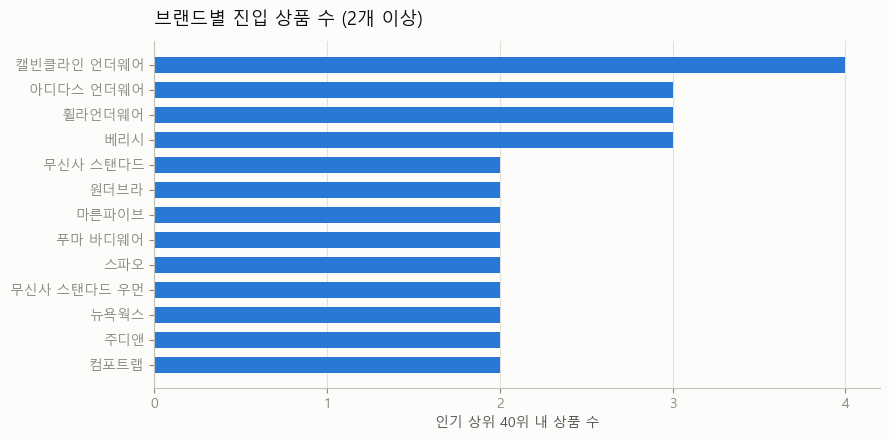

1개 상품 브랜드: 9개


In [6]:
brand_cnt = prod['Brand'].value_counts()
top = brand_cnt[brand_cnt >= 2].sort_values()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top.index, top.values, color=BLUE, height=0.62)
ax.set_xlabel('인기 상위 40위 내 상품 수')
ax.set_title('브랜드별 진입 상품 수 (2개 이상)', loc='left', fontsize=13, pad=12)
ax.set_xticks(range(0, top.max() + 1))
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

print(f"1개 상품 브랜드: {(brand_cnt == 1).sum()}개")

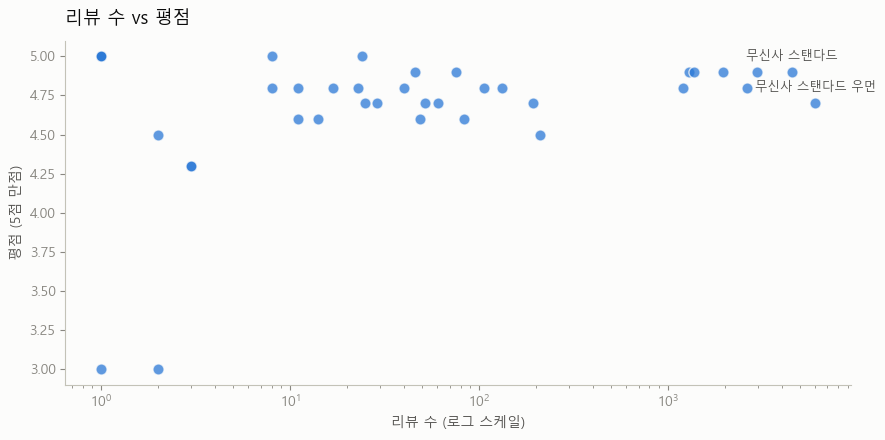

In [7]:
# 리뷰수(누적 판매 프록시) vs 평점 — 리뷰가 있는 상품만
p = prod[prod['평점'] > 0]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(p['리뷰수'], p['평점'], s=64, color=BLUE, alpha=0.75, edgecolor=SURFACE, linewidth=1)
ax.set_xscale('log')
for _, row in p.nlargest(2, '리뷰수').iterrows():
    ax.annotate(row['Brand'], (row['리뷰수'], row['평점']),
                textcoords='offset points', xytext=(0, 9), ha='center', fontsize=9, color=SECONDARY)
ax.set_xlabel('리뷰 수 (로그 스케일)')
ax.set_ylabel('평점 (5점 만점)')
ax.set_title('리뷰 수 vs 평점', loc='left', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

**글로벌 언더웨어 브랜드 + 자체 브랜드(PB)의 양강 구도**

- 진입 상품 수는 캘빈클라인(4개), 베리시·아디다스·휠라(각 3개) 순 — 라이선스/글로벌 스포츠 언더웨어가 상위권을 넓게 점유
- 리뷰 수(누적 판매의 프록시)로 보면 무신사 스탠다드 우먼(6,042건)·무신사 스탠다드(4,524건)가 압도적 — 진입 상품 수는 적지만 개별 상품의 판매 볼륨은 PB가 지배
- 평점은 리뷰 수와 무관하게 4.5~5.0에 몰려 있음 → 다음 절에서 확인

#### 4. 평점 분포 — 평점은 변별력이 있는가

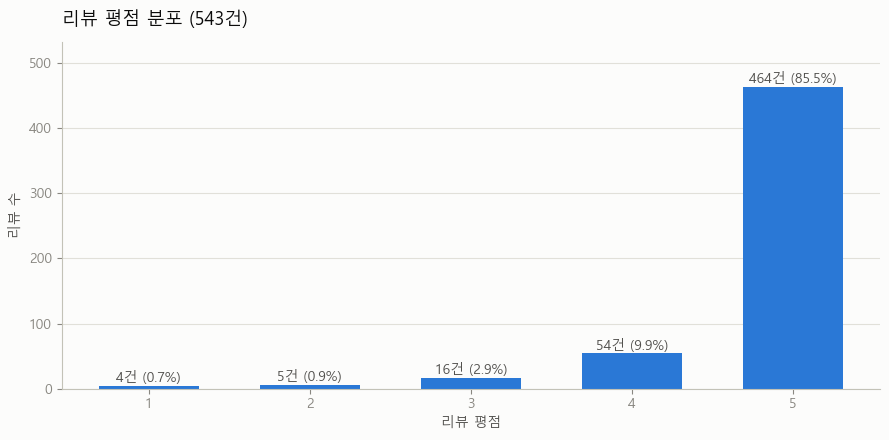

In [8]:
dist = rev['평점'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(dist.index, dist.values, color=BLUE, width=0.62)
for b, v in zip(bars, dist.values):
    ax.text(b.get_x() + b.get_width() / 2, v + 6, f'{v}건 ({v / len(rev):.1%})',
            ha='center', fontsize=10, color=SECONDARY)
ax.set_xlabel('리뷰 평점')
ax.set_ylabel('리뷰 수')
ax.set_ylim(0, dist.max() * 1.15)
ax.set_title('리뷰 평점 분포 (543건)', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

**평점의 95.4%가 4점 이상 — 평점만으로는 상품을 변별할 수 없다**

- 5점 464건(85.5%), 4점 54건(9.9%), 3점 이하는 25건(4.6%)에 불과
- 상품 단위 평점도 리뷰가 있는 37개 중 평균 4.67, 최저 3.0으로 상향 압축 — 전형적인 평점 인플레이션
- 결론: 이 카테고리에서 정보 가치는 별점이 아니라 **리뷰 본문**, 특히 소수의 저평점 리뷰에 있다

#### 5. 리뷰 텍스트 — 무엇에 만족하고 무엇에 불만인가

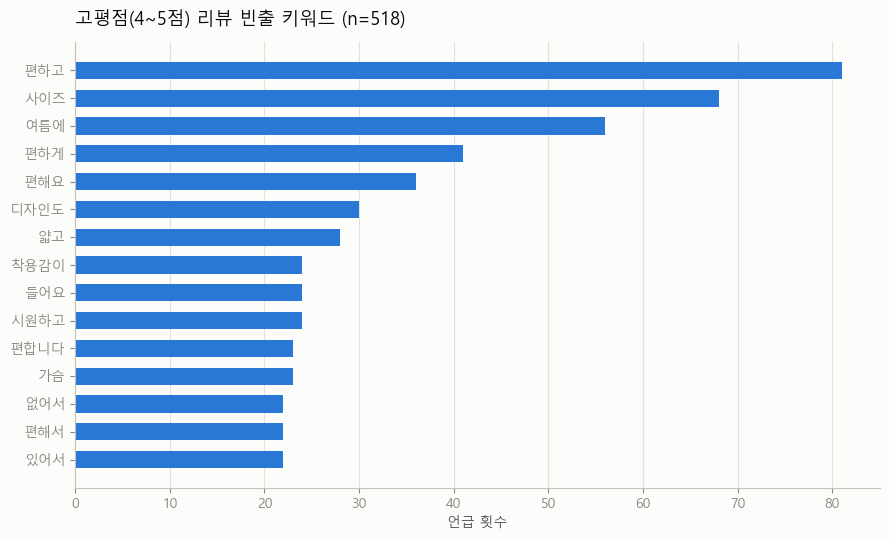

In [9]:
# 간단 토큰화(2글자 이상 한글) + 범용 표현 불용어 제거
STOP = set('있어요 있습니다 같아요 그리고 너무 정말 진짜 그냥 조금 아주 많이 잘 더 좀 것 수 때 거 '
           '저는 제가 근데 하고 입니다 있는 없이 같은 살짝 완전 계속 다시 하나 해서 위에 이번 다른 '
           '이거 봐요 봐서 그래서 하는 한 번 안 못 딱 좋아요 좋습니다 좋아서 좋고 좋음 굿 최고 '
           '만족합니다 만족해요 않고 엄청 생각보다 좋네요 마음에 입기 입고 입을 입어도'.split())

def tokens(text):
    return [t for t in re.findall(r'[가-힣]{2,}', str(text)) if t not in STOP]

hi = rev[rev['평점'] >= 4]
lo = rev[rev['평점'] <= 3]

top15 = pd.Series(Counter(t for s in hi['Review Body'] for t in tokens(s))).nlargest(15)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh(top15.index[::-1], top15.values[::-1], color=BLUE, height=0.62)
ax.set_xlabel('언급 횟수')
ax.set_title(f'고평점(4~5점) 리뷰 빈출 키워드 (n={len(hi)})', loc='left', fontsize=13, pad=12)
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

고평점 리뷰의 언어는 **착용감(편하고·편하게·편해요), 사이즈, 계절성(여름에), 소재(얇고), 디자인**으로 요약된다.
속옷/홈웨어의 구매 만족은 기능적 편안함이 압도적 1순위이고, 수집 시점(7월)에 맞물린 '여름 시원함' 언급이 상위권 — 시즌성이 강한 카테고리.

형태소 분석기 없이 조사가 붙은 형태('편하고/편하게/편해요')가 분리되어 잡히는 한계가 있어,
아래에서는 속성 사전 기반으로 언급률을 직접 집계해 보완한다.

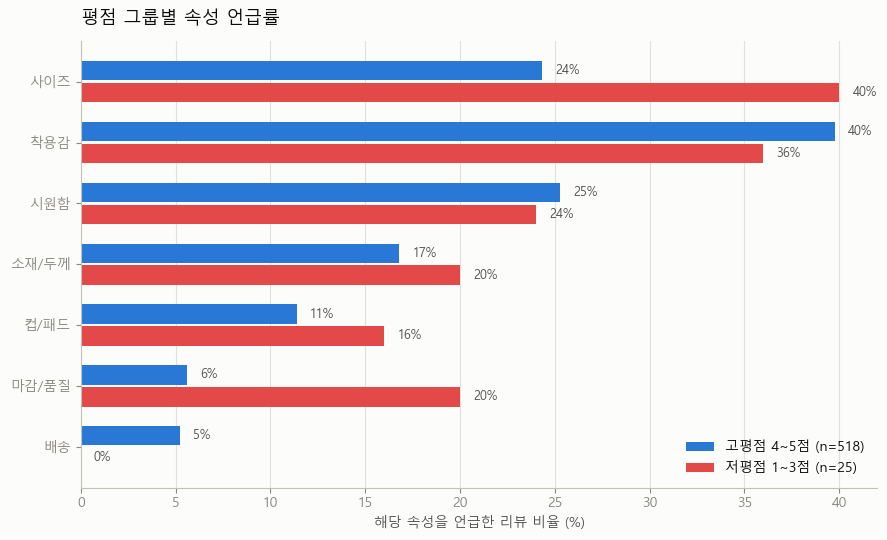

,고평점(4~5점),저평점(1~3점)
사이즈,24.3,40.0
착용감,39.8,36.0
시원함,25.3,24.0
소재/두께,16.8,20.0
컵/패드,11.4,16.0
마감/품질,5.6,20.0
배송,5.2,0.0


In [10]:
# 속성 사전 기반 언급률: 고평점 vs 저평점
ASPECTS = {
    '사이즈': '사이즈|크기',
    '착용감': '편하|편안|불편',
    '시원함': '시원|여름|쿨',
    '소재/두께': '얇|소재|원단|두께',
    '컵/패드': '컵|와이어|패드|뽕',
    '마감/품질': '마감|봉제|박음질|실밥|품질',
    '배송': '배송',
}
rates = pd.DataFrame({
    '고평점(4~5점)': [hi['Review Body'].str.contains(p).mean() * 100 for p in ASPECTS.values()],
    '저평점(1~3점)': [lo['Review Body'].str.contains(p).mean() * 100 for p in ASPECTS.values()],
}, index=ASPECTS.keys())

y = range(len(rates))
h = 0.36
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.barh([i - h / 2 for i in y], rates['고평점(4~5점)'], height=h - 0.04, color=BLUE, label=f'고평점 4~5점 (n={len(hi)})')
ax.barh([i + h / 2 for i in y], rates['저평점(1~3점)'], height=h - 0.04, color=RED, label=f'저평점 1~3점 (n={len(lo)})')
for i, (hv, lv) in enumerate(zip(rates['고평점(4~5점)'], rates['저평점(1~3점)'])):
    ax.text(hv + 0.7, i - h / 2, f'{hv:.0f}%', va='center', fontsize=9, color=SECONDARY)
    ax.text(lv + 0.7, i + h / 2, f'{lv:.0f}%', va='center', fontsize=9, color=SECONDARY)
ax.set_yticks(list(y))
ax.set_yticklabels(rates.index)
ax.invert_yaxis()
ax.set_xlabel('해당 속성을 언급한 리뷰 비율 (%)')
ax.set_title('평점 그룹별 속성 언급률', loc='left', fontsize=13, pad=12)
ax.legend(frameon=False, loc='lower right')
ax.grid(True, axis='x')
plt.tight_layout()
plt.show()

rates.round(1)

**저평점 리뷰에서 튀는 속성이 이 카테고리의 구매 리스크다**

| 속성 | 고평점 | 저평점 | 배율 |
|---|---|---|---|
| 마감/품질 | 5.6% | 20.0% | **3.6×** |
| 사이즈 | 24.3% | 40.0% | 1.6× |
| 컵/패드 | 11.4% | 16.0% | 1.4× |
| 배송 | 5.2% | 0.0% | — |

- **마감/품질**(실밥, 봉제)이 저평점에서 언급률이 가장 크게 뛴다 — 불만의 핵심 동인
- **사이즈**는 만족 리뷰에서도 많이 언급되지만(정보 공유 목적), 저평점에서는 '작게 나옴', '컵이 안 맞음' 같은 실패 경험으로 등장
- **배송**은 저평점에서 0% — 무신사 물류에 대한 불만은 사실상 없음. 불만은 전적으로 상품 자체에서 발생
- 저평점 표본이 25건으로 작다는 점은 유의(수치는 방향성 해석 용도)

#### 종합 인사이트

1. **가격**: 인기 상품은 1~5만원(중앙값 3.2만원)에 집중, 세트 상품이 우측 꼬리를 형성. 절반이 25%+ 상시할인 상태라 실판매가 기준 비교가 필수
2. **브랜드**: 진입 폭은 글로벌 언더웨어(캘빈클라인·아디다스·휠라), 판매 볼륨은 무신사 스탠다드(PB)가 지배하는 이원 구조
3. **평점**: 95%가 4점 이상으로 변별력 없음 → 상품 평가는 리뷰 텍스트, 특히 4.6%의 저평점 리뷰에서 읽어야 함
4. **불만 구조**: 마감/품질 이슈가 저평점의 최대 동인(언급률 3.6배), 그 다음이 사이즈 실패. 배송 불만은 없음
5. **MD 관점 시사점**: 이 카테고리에서 상품 페이지가 해결해야 할 정보는 '사이즈 실패 방지'(상세 실측, 컵 스펙)와 '품질 신뢰'(마감 클로즈업). 리뷰 이벤트로 별점을 쌓는 것은 변별력이 없어 효과 제한적

**데이터 한계**
- 특정 시점(2026-07-08) 스냅샷, 인기순 상위 40개 표본 — 계절(여름) 편향 존재
- 리뷰는 '도움돼요' 순 상위 표집이라 장문·정보성 리뷰로 편향
- 속옷 카테고리는 플랫폼이 리뷰어 신체정보를 마스킹(`showUserProfile=False`)해 키/몸무게 기반 사이즈 분석 불가 — 구매 옵션 문자열이 대안
- 저평점 리뷰 25건: 속성 언급률은 방향성 참고용